Classification with a ResNet 50 trained on ImageNet

In [1]:
!pip install git+https://github.com/drapado/d2l-wur.git
!pip install scipy --quiet
!pip install torchmetrics --quiet
!pip install torch-summary --quiet

  Cloning https://github.com/drapado/d2l-wur.git to /tmp/pip-req-build-5_uljni0
  Running command git clone --filter=blob:none --quiet https://github.com/drapado/d2l-wur.git /tmp/pip-req-build-5_uljni0
  Resolved https://github.com/drapado/d2l-wur.git to commit fe9e2db3f28092dc60ea8d317e72dd708f57cfb5
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.6 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.8 MB/s eta 0:00:00
  Created wheel for d2l: filename=d2l-1.0.3-py3-none-any.whl size=111669 sha256=1c84c4803c22193b82902ad85c4b5e746d369a1a85d1b9524c07d8f0baf1d6e3
  Stored in directory: /tmp/pip-ephem-wheel-cache-_n4u0ci2/wheels/ea/d2/2e/f8b68fe88c17f8a47b9e7b1251059edfd0c4122db1e993b83e
Successfully built d2l
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install -q torch torchvision pandas Pillow

from d2l import torch as d2l
import urllib
from PIL import Image
from torchvision import transforms
import torch
import torch.nn as nn
import pandas as pd

In [12]:
!git clone https://git.wur.nl/abe-datasets/education/fruit-detection-challenge.git

Cloning into 'fruit-detection-challenge'...
remote: Enumerating objects: 2010, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 2010 (delta 2), reused 0 (delta 0), pack-reused 2004 (from 1)
Receiving objects: 100% (2010/2010), 255.89 MiB | 18.39 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (1958/1958), done.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


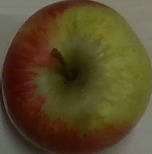

In [4]:
filename = '/content/drive/MyDrive/Deep Learning/fruit-detection-project/image_3.jpg'
img = Image.open(filename).convert('RGB')
img

In [5]:
from torchvision.models import resnet50, ResNet50_Weights

#TODO: Check the documentation and create a resnet50 with ImageNet (IMAGENET1K_V2) weights
weights = ResNet50_Weights.IMAGENET1K_V2
resnet50 = resnet50(weights=weights)

# setting the ResNet to eval() disables dropout and sets BatchNorm layers to training mode
resnet50.eval()

# print the architecture
resnet50

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
transform = weights.transforms()
print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Original image type and size: <class 'PIL.Image.Image'>, (152, 154)
New image type and size: <class 'torch.Tensor'>, torch.Size([1, 3, 224, 224])


min: -1.90 max: 0.29, mean: -0.86, std: 0.56


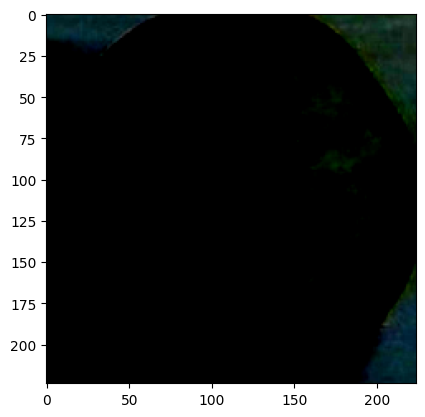

In [7]:
print(f"Original image type and size: {type(img)}, {img.size}")
tensor = transform(img).unsqueeze(0) # transform and add batch dimension
print(f"New image type and size: {type(tensor)}, {tensor.shape}")
print(f"min: {tensor.min():.2f} max: {tensor.max():.2f}, mean: {tensor.mean():.2f}, std: {tensor.std():.2f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.imshow(tensor.numpy()[0].transpose(1,2,0))

In [8]:
categories = weights.meta["categories"]
# classes
print(", ".join(categories))

tench, goldfish, great white shark, tiger shark, hammerhead, electric ray, stingray, cock, hen, ostrich, brambling, goldfinch, house finch, junco, indigo bunting, robin, bulbul, jay, magpie, chickadee, water ouzel, kite, bald eagle, vulture, great grey owl, European fire salamander, common newt, eft, spotted salamander, axolotl, bullfrog, tree frog, tailed frog, loggerhead, leatherback turtle, mud turtle, terrapin, box turtle, banded gecko, common iguana, American chameleon, whiptail, agama, frilled lizard, alligator lizard, Gila monster, green lizard, African chameleon, Komodo dragon, African crocodile, American alligator, triceratops, thunder snake, ringneck snake, hognose snake, green snake, king snake, garter snake, water snake, vine snake, night snake, boa constrictor, rock python, Indian cobra, green mamba, sea snake, horned viper, diamondback, sidewinder, trilobite, harvestman, scorpion, black and gold garden spider, barn spider, garden spider, black widow, tarantula, wolf spide

In [9]:
with torch.no_grad(): # this is optional, but reduces computations (no gradients)
    # TODO: predict a class probability using the image tensor and resnet50
    logits = resnet50(tensor)
    y_scores = torch.nn.functional.softmax(logits, dim=1)

In [10]:
index_max_class = torch.argmax(y_scores, dim=1).item()
print(f"Predicted class: {categories[index_max_class]}, with probability {y_scores[0,index_max_class]:.4f}")

Predicted class: Granny Smith, with probability 0.3667


# Fine-tuning ResNet50 for fruit classification (based on week2_03)

### Creating the data loader

In [13]:
import torchvision
import os
import random
data_dir = "fruit-detection-challenge/classification"

train_imgs = torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train'))
val_imgs = torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'val'))

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

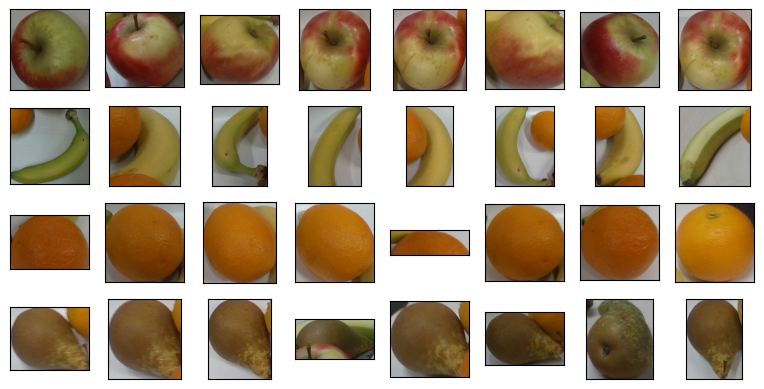

In [14]:
# Visualize 8 images per class

apple = [img for img, y in train_imgs if y == 0][:8]
banana = [img for img, y in train_imgs if y == 1][:8]
orange = [img for img, y in train_imgs if y == 2][:8]
pear = [img for img, y in train_imgs if y == 3][:8]

d2l.show_images(apple + banana + orange + pear, 4, 8, scale=1.2)

During training, we first crop a random area with random size and random aspect ratio from the image and then scale the area to an input with a height and width of 224 pixels. During testing, we scale the height and width of images to 256 pixels, and then crop the center area with height and width of 224 pixels to use as the input. In addition, we normalize the values of the three RGB (red, green, and blue) color channels. The average of all values of the channel is subtracted from each value and then the result is divided by the standard deviation of all values of the channel to produce the output.

In [15]:
# We specify the mean and variance of the three RGB channels to normalize the
# image channel
normalize = torchvision.transforms.Normalize(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize])

test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize])

In [16]:
# check the in and out of the fc layer of resnet50

resnet50.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [17]:
finetune_resnet50 = resnet50
finetune_resnet50.fc = nn.Linear(finetune_resnet50.fc.in_features, 4) # we modify the out featuere to our 4 classes
nn.init.xavier_uniform_(finetune_resnet50.fc.weight); # initialize the weights of the new fc layer

In [18]:
def train_fine_tuning(net, learning_rate, batch_size=128, num_epochs=5, param_group=True):
    train_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_augs),
        batch_size=batch_size, shuffle=True
    )
    val_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=test_augs),
        batch_size=batch_size, shuffle=False
    )

    devices = d2l.try_all_gpus()
    loss = nn.CrossEntropyLoss(reduction="none")

    if param_group:
        params_1x = [p for name, p in net.named_parameters() if name not in ["fc.weight", "fc.bias"]]
        trainer = torch.optim.SGD(
            [{'params': params_1x},
             {'params': net.fc.parameters(), 'lr': learning_rate * 10}],
            lr=learning_rate, weight_decay=0.001
        )
    else:
        trainer = torch.optim.SGD(net.parameters(), lr=learning_rate, weight_decay=0.001)

    d2l.train_ch13(net, train_iter, val_iter, loss, trainer, num_epochs, devices)

loss 0.240, train acc 0.925, test acc 0.972
91.3 examples/sec on [device(type='cuda', index=0)]


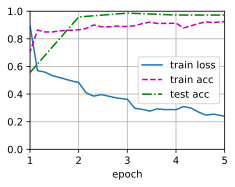

In [19]:
train_fine_tuning(finetune_resnet50, 5e-5)